In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

import joblib, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [41]:
df = pd.read_csv('../data/processed_dataset.csv')

In [42]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,stops_num,dep_time_num,arr_time_num,is_business,urgency_num,duration_sq
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,0,3,4,0,3,4.7089
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,0,0,1,0,3,5.4289
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,0,0,0,0,3,4.7089
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,0,1,2,0,3,5.0625
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,0,1,1,0,3,5.4289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,1,1,3,1,1,101.6064
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,1,2,4,1,1,108.5764
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,1,0,4,1,1,191.2689
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,1,0,3,1,1,100.0000


In [43]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,stops_num,dep_time_num,arr_time_num,is_business,urgency_num,duration_sq
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,0,3,4,0,3,4.7089
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,0,0,1,0,3,5.4289
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,0,0,0,0,3,4.7089
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,0,1,2,0,3,5.0625
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,0,1,1,0,3,5.4289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,1,1,3,1,1,101.6064
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,1,2,4,1,1,108.5764
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,1,0,4,1,1,191.2689
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,1,0,3,1,1,100.0000


In [44]:
df = pd.read_csv('../data/processed_dataset.csv')

CAT_COLS = ['airline', 'source_city', 'destination_city',
            'departure_time', 'arrival_time', 'stops','class']

NUM_COLS = ['duration', 'duration_sq', 'days_left',
            'stops_num', 'dep_time_num', 'arr_time_num',
             'urgency_num','is_business']

X = df[CAT_COLS + NUM_COLS]
y = np.log1p(df['price'])

print(X.shape)
X.head(3)

(300153, 15)


,airline,source_city,destination_city,departure_time,arrival_time,stops,class,duration,duration_sq,days_left,stops_num,dep_time_num,arr_time_num,urgency_num,is_business
0,SpiceJet,Delhi,Mumbai,Evening,Night,zero,Economy,2.17,4.7089,1,0,3,4,3,0
1,SpiceJet,Delhi,Mumbai,Early_Morning,Morning,zero,Economy,2.33,5.4289,1,0,0,1,3,0
2,AirAsia,Delhi,Mumbai,Early_Morning,Early_Morning,zero,Economy,2.17,4.7089,1,0,0,0,3,0


In [45]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['class'])

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
    stratify=df.loc[X_temp.index, 'class'])

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (240122, 15) | Val: (30015, 15) | Test: (30016, 15)


In [46]:

lr_preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('scaler', StandardScaler(), NUM_COLS)
])

xgb_preprocessor = ColumnTransformer([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value=-1), CAT_COLS),
    ('num', 'passthrough', NUM_COLS)
])



In [47]:
def evaluate(name, pipeline, X_tr, y_tr, X_vl, y_vl):
    tr_pred = pipeline.predict(X_tr)
    vl_pred = pipeline.predict(X_vl)
    
    row = {
        'Model':      name,
        'Train R²':   r2_score(y_tr, tr_pred),
        'Val R²':     r2_score(y_vl, vl_pred),
        'Train RMSE': np.sqrt(mean_squared_error(np.expm1(y_tr), np.expm1(tr_pred))),
        'Val RMSE':   np.sqrt(mean_squared_error(np.expm1(y_vl), np.expm1(vl_pred))),
        'Val MAE':    mean_absolute_error(np.expm1(y_vl), np.expm1(vl_pred)),
    }
    return row

all_results = []

In [48]:
lr_base = Pipeline([
    ('pre', lr_preprocessor),
    ('model', LinearRegression())
])

lr_base.fit(X_train, y_train)

res = evaluate('LR baseline', lr_base, X_train, y_train, X_val, y_val)
all_results.append(res)
print(res)

{'Model': 'LR baseline', 'Train R²': 0.9182214130487061, 'Val R²': 0.9165116053424335, 'Train RMSE': np.float64(8068.180037589551), 'Val RMSE': np.float64(8164.451063289172), 'Val MAE': 4685.195118480685}


In [49]:
lr_search = Pipeline([
    ('pre', lr_preprocessor),
    ('model', Ridge())
])

param_dist = {
    'model__alpha': uniform(0.01, 100)
}

ridge_rs = RandomizedSearchCV(
    lr_search, param_dist,
    n_iter=5, scoring='r2', cv=2,
    n_jobs=-1, random_state=42, verbose=1
)

ridge_rs.fit(X_train, y_train)

print(f"Best alpha: {ridge_rs.best_params_}")
print(f"Best CV R²: {ridge_rs.best_score_:.4f}")

res = evaluate('Ridge (tuned)', ridge_rs, X_train, y_train, X_val, y_val)
all_results.append(res)
print(res)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best alpha: {'model__alpha': np.float64(15.611864044243651)}
Best CV R²: 0.9182
{'Model': 'Ridge (tuned)', 'Train R²': 0.9182213937763634, 'Val R²': 0.9165117808669202, 'Train RMSE': np.float64(8067.666575158303), 'Val RMSE': np.float64(8163.894810682581), 'Val MAE': 4685.032883572764}


In [50]:
xgb_base = Pipeline([
    ('pre', xgb_preprocessor),
    ('model', XGBRegressor(n_estimators=300, random_state=42,
                           tree_method='hist', verbosity=0))
])

xgb_base.fit(X_train, y_train)

res = evaluate('XGB baseline', xgb_base, X_train, y_train, X_val, y_val)
all_results.append(res)
print(res)

{'Model': 'XGB baseline', 'Train R²': 0.981067009979926, 'Val R²': 0.9783053205587935, 'Train RMSE': np.float64(3203.403062359733), 'Val RMSE': np.float64(3365.7624549438274), 'Val MAE': 1802.59080497593}


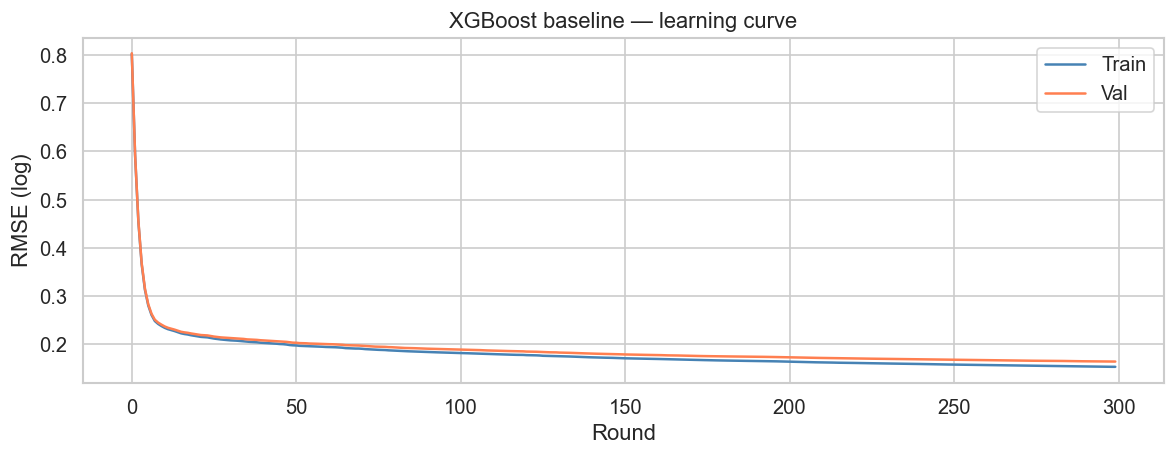

In [51]:

xgb_pre = xgb_preprocessor.fit(X_train)
X_train_xgb = xgb_pre.transform(X_train)
X_val_xgb   = xgb_pre.transform(X_val)

xgb_eval = XGBRegressor(n_estimators=300, random_state=42,
                         tree_method='hist', verbosity=0)
xgb_eval.fit(X_train_xgb, y_train,
             eval_set=[(X_train_xgb, y_train), (X_val_xgb, y_val)],
             verbose=False)

r = xgb_eval.evals_result()
plt.figure(figsize=(10, 4))
plt.plot(r['validation_0']['rmse'], label='Train', color='steelblue')
plt.plot(r['validation_1']['rmse'], label='Val',   color='coral')
plt.xlabel('Round')
plt.ylabel('RMSE (log)')
plt.title('XGBoost baseline — learning curve')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/xgb_baseline_curve.png', bbox_inches='tight')
plt.show()

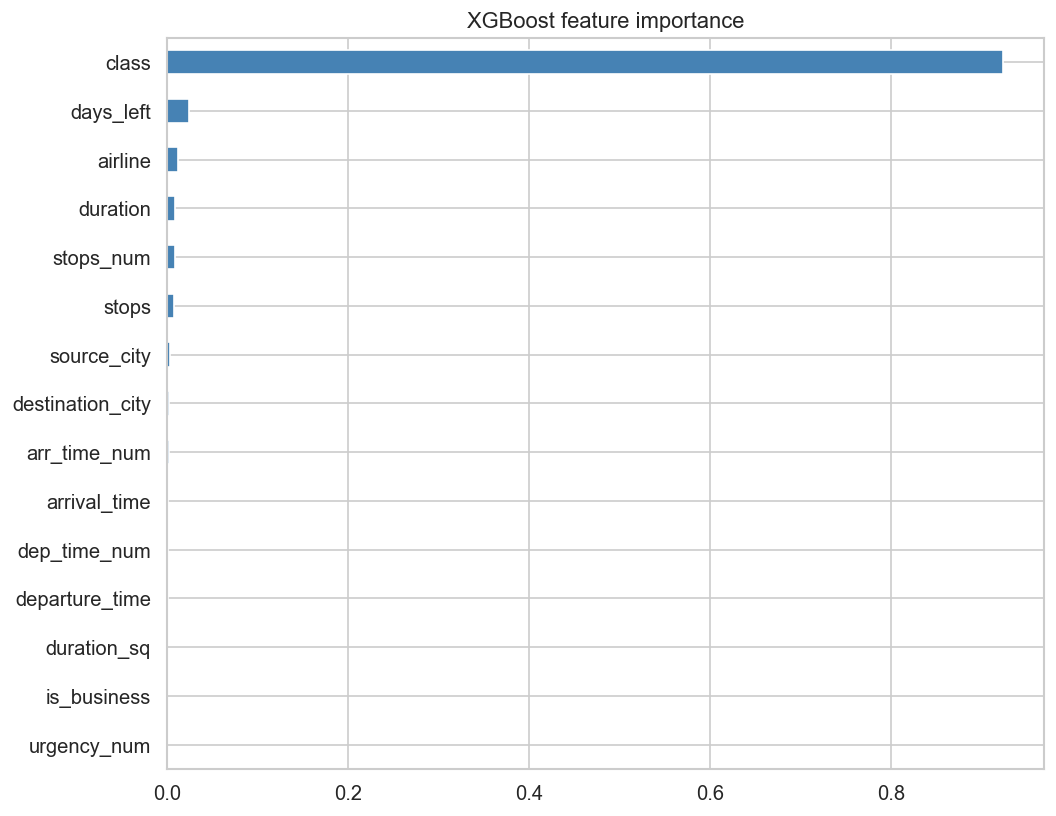

In [52]:
feat_names = (xgb_pre.named_transformers_['ord']
              .get_feature_names_out(CAT_COLS).tolist() + NUM_COLS)

importance = pd.Series(xgb_eval.feature_importances_,
                        index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost feature importance')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', bbox_inches='tight')
plt.show()

In [53]:
xgb_search_pipe = Pipeline([
    ('pre', xgb_preprocessor),
    ('model', XGBRegressor(random_state=42, tree_method='hist', verbosity=0))
])

param_dist = {
    'model__n_estimators':     randint(200, 800),
    'model__max_depth':        randint(3, 10),
    'model__learning_rate':    uniform(0.01, 0.29),
    'model__subsample':        uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 10),
    'model__reg_alpha':        uniform(0, 1),
    'model__reg_lambda':       uniform(1, 4),
}

xgb_rs = RandomizedSearchCV(
    xgb_search_pipe, param_dist,
    n_iter=10, scoring='r2', cv=2,
    n_jobs=-1, random_state=42, verbose=1
)

xgb_rs.fit(X_train, y_train)

print(f"Best CV R²: {xgb_rs.best_score_:.4f}")
print(f"Best params: {xgb_rs.best_params_}")

res = evaluate('XGB tuned', xgb_rs, X_train, y_train, X_val, y_val)
all_results.append(res)
print(res)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best CV R²: 0.9823
Best params: {'model__colsample_bytree': np.float64(0.6557975442608167), 'model__learning_rate': np.float64(0.09472194807521325), 'model__max_depth': 9, 'model__min_child_weight': 3, 'model__n_estimators': 766, 'model__reg_alpha': np.float64(0.9832308858067882), 'model__reg_lambda': np.float64(2.8670515729919197), 'model__subsample': np.float64(0.9439761626945282)}
{'Model': 'XGB tuned', 'Train R²': 0.988550168946933, 'Val R²': 0.9842455136212654, 'Train RMSE': np.float64(2421.278224753906), 'Val RMSE': np.float64(2762.0038040113513), 'Val MAE': 1376.9209406242517}


In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt


In [55]:
preprocessor = ColumnTransformer([
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('scaler', StandardScaler(), NUM_COLS)
])

X_train_nn = preprocessor.fit_transform(X_train)
X_val_nn   = preprocessor.transform(X_val)
X_test_nn  = preprocessor.transform(X_test)

y_train_np = y_train.values
y_val_np   = y_val.values
y_test_np  = y_test.values

print(f"Input shape: {X_train_nn.shape}")

Input shape: (240122, 43)


In [56]:
def build_baseline(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

baseline = build_baseline(X_train_nn.shape[1])
baseline.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,017 (211.00 KB)

 Trainable params: 53,249 (208.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [57]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

history = baseline.fit(
    X_train_nn, y_train_np,
    validation_data=(X_val_nn, y_val_np),
    epochs=100,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3.1583 - mae: 1.0081 - val_loss: 0.1068 - val_mae: 0.2515 - learning_rate: 0.0010
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4480 - mae: 0.5314 - val_loss: 0.1177 - val_mae: 0.2672 - learning_rate: 0.0010
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3830 - mae: 0.4915 - val_loss: 0.1224 - val_mae: 0.2710 - learning_rate: 0.0010
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3362 - mae: 0.4608 - val_loss: 0.0862 - val_mae: 0.2265 - learning_rate: 0.0010
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3058 - mae: 0.4390 - val_loss: 0.0915 - val_mae: 0.2296 - learning_rate: 0.0010
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2789 - mae: 0.4188 - val_loss: 0.1104 - val_mae: 0.2514 - learning_rate: 0.0010
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2481 - mae: 0.3953 - val_loss: 0.1031 - val_mae: 0.2557 - learning_rate: 0.0010

In [58]:
def evaluate_nn(name, model, X, y_true_log):
    pred_log = model.predict(X, verbose=0).flatten()
    pred_inr = np.expm1(pred_log)
    true_inr = np.expm1(y_true_log)
    
    r2   = r2_score(y_true_log, pred_log)
    rmse = np.sqrt(mean_squared_error(true_inr, pred_inr))
    mae  = mean_absolute_error(true_inr, pred_inr)
    
    print(f"\n=== {name} ===")
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: Rs. {rmse:,.0f}")
    print(f"MAE:  Rs. {mae:,.0f}")
    return r2

evaluate_nn('Baseline - Train', baseline, X_train_nn, y_train_np)
evaluate_nn('Baseline - Val',   baseline, X_val_nn,   y_val_np)


=== Baseline - Train ===
R²:   0.9775
RMSE: Rs. 3,703
MAE:  Rs. 1,914

=== Baseline - Val ===
R²:   0.9750
RMSE: Rs. 3,831
MAE:  Rs. 1,992


0.9749877424326246

In [59]:


def build_tunable(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))

    # tune number of layers
    for i in range(hp.Int('n_layers', 2, 5)):
        model.add(layers.Dense(
            units=hp.Choice(f'units_{i}', [64, 128, 256, 512]),
            activation=hp.Choice(f'act_{i}', ['relu', 'elu', 'selu'])
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(
            rate=hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)
        ))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='log')
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

In [60]:
tuner = kt.RandomSearch(
    build_tunable,
    objective='val_loss',
    max_trials=3,
    executions_per_trial=1,
    directory='../models/kt_search',
    project_name='flight_price_ann',
    overwrite=True
)

tuner.search(
    X_train_nn, y_train_np,
    validation_data=(X_val_nn, y_val_np),
    epochs=60,
    batch_size=512,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                             restore_best_weights=True)],
    verbose=1
)

tuner.results_summary()

Trial 3 Complete [00h 02m 59s]
val_loss: 0.04568275809288025

Best val_loss So Far: 0.04113161191344261
Total elapsed time: 00h 09m 25s
Results summary
Results in ../models/kt_search\flight_price_ann
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0 summary
Hyperparameters:
n_layers: 3
units_0: 128
act_0: elu
dropout_0: 0.30000000000000004
units_1: 512
act_1: relu
dropout_1: 0.1
lr: 0.0002607860606751251
units_2: 64
act_2: relu
dropout_2: 0.1
Score: 0.04113161191344261

Trial 2 summary
Hyperparameters:
n_layers: 3
units_0: 64
act_0: elu
dropout_0: 0.1
units_1: 64
act_1: relu
dropout_1: 0.30000000000000004
lr: 0.0004918694064742597
units_2: 512
act_2: selu
dropout_2: 0.2
Score: 0.04568275809288025

Trial 1 summary
Hyperparameters:
n_layers: 2
units_0: 512
act_0: relu
dropout_0: 0.30000000000000004
units_1: 64
act_1: elu
dropout_1: 0.5
lr: 0.00025880925342103354
units_2: 64
act_2: selu
dropout_2: 0.1
Score: 0.05554555356502533


In [61]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters found:")
print(f"  n_layers:      {best_hp.get('n_layers')}")
print(f"  learning_rate: {best_hp.get('lr'):.6f}")

for i in range(best_hp.get('n_layers')):
    print(f"  Layer {i}: units={best_hp.get(f'units_{i}')}  "
          f"act={best_hp.get(f'act_{i}')}  "
          f"dropout={best_hp.get(f'dropout_{i}')}")

Best hyperparameters found:
  n_layers:      3
  learning_rate: 0.000261
  Layer 0: units=128  act=elu  dropout=0.30000000000000004
  Layer 1: units=512  act=relu  dropout=0.1
  Layer 2: units=64  act=relu  dropout=0.1


In [62]:
best_model = tuner.hypermodel.build(best_hp)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-7, verbose=1)
]

history_tuned = best_model.fit(
    X_train_nn, y_train_np,
    validation_data=(X_val_nn, y_val_np),
    epochs=200,
    batch_size=hp.Choice if False else best_hp.get('batch_size')
        if 'batch_size' in best_hp.values else 512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 69.5331 - mae: 8.2442 - val_loss: 41.0294 - val_mae: 6.3893 - learning_rate: 2.6079e-04
Epoch 2/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 21.6252 - mae: 4.3211 - val_loss: 4.2390 - val_mae: 2.0246 - learning_rate: 2.6079e-04
Epoch 3/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.7904 - mae: 1.3141 - val_loss: 0.1541 - val_mae: 0.3090 - learning_rate: 2.6079e-04
Epoch 4/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.3695 - mae: 0.8920 - val_loss: 0.0887 - val_mae: 0.2288 - learning_rate: 2.6079e-04
Epoch 5/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.1435 - mae: 0.8170 - val_loss: 0.0832 - val_mae: 0.2208 - learning_rate: 2.6079e-04
Epoch 6/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9682 - mae: 0.7551 - val_loss: 0.0775 - val_mae: 0.2099 - learning_rate: 2.6079e-04
Epoch 7/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.8332 - mae: 0.7008 - val_loss: 0.0753 - val_mae: 0.2

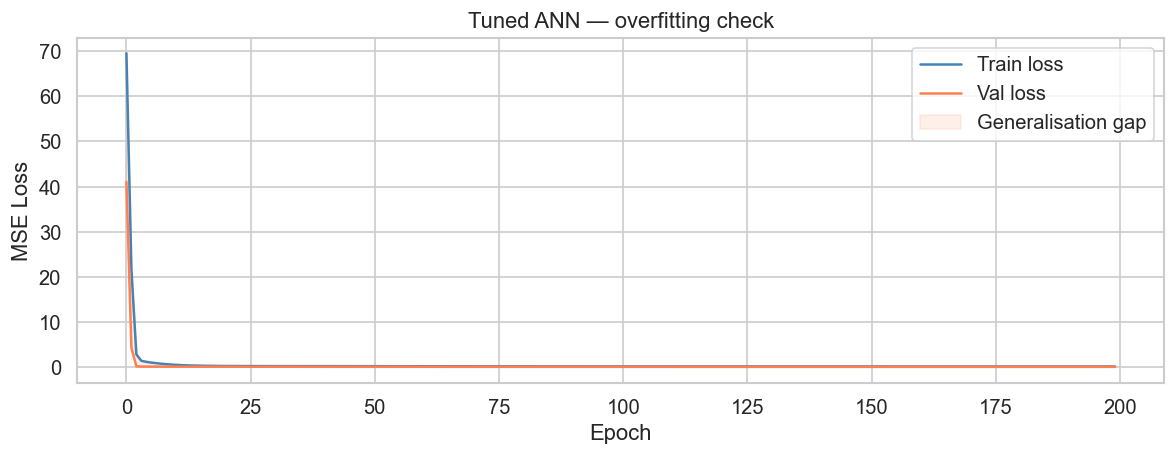

In [63]:

train_loss = history_tuned.history['loss']
val_loss   = history_tuned.history['val_loss']
gap        = [v - t for t, v in zip(train_loss, val_loss)]

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train loss', color='steelblue')
plt.plot(val_loss,   label='Val loss',   color='coral')
plt.fill_between(range(len(gap)),
                 train_loss,
                 val_loss,
                 alpha=0.12, color='coral', label='Generalisation gap')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Tuned ANN — overfitting check')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/ann_overfit_check.png', bbox_inches='tight')
plt.show()

In [64]:
evaluate_nn('Tuned ANN — Train', best_model, X_train_nn, y_train_np)
evaluate_nn('Tuned ANN — Val',   best_model, X_val_nn,   y_val_np)


=== Tuned ANN — Train ===
R²:   0.9739
RMSE: Rs. 3,989
MAE:  Rs. 2,081

=== Tuned ANN — Val ===
R²:   0.9717
RMSE: Rs. 4,094
MAE:  Rs. 2,146


0.9716897822734306

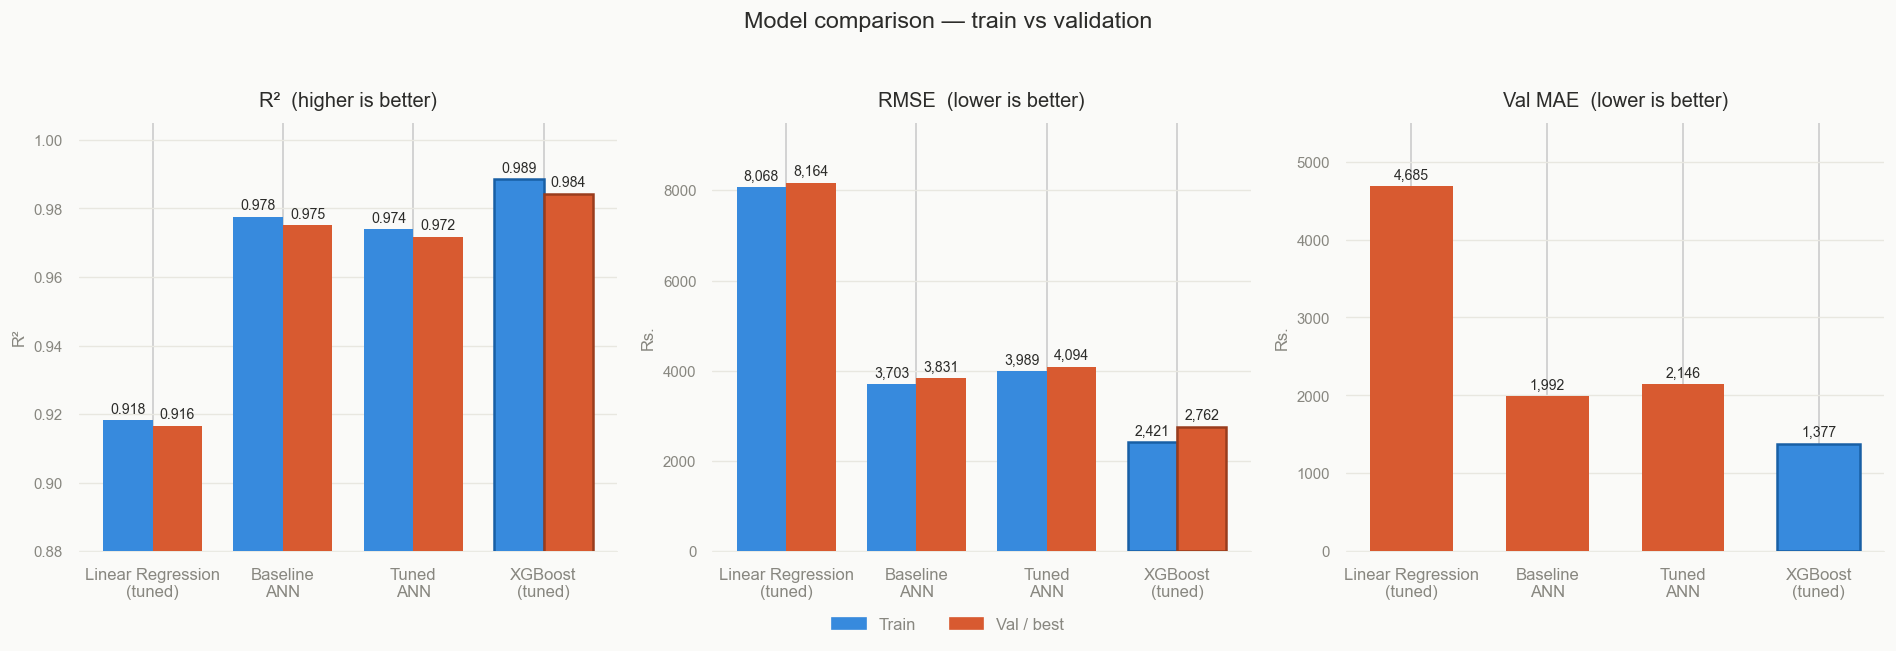

In [65]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models      = ['Linear Regression\n(tuned)', 'Baseline\nANN', 'Tuned\nANN', 'XGBoost\n(tuned)']
train_r2    = [0.9182,  0.9775,  0.9739,  0.9885]
val_r2      = [0.9165,  0.9750,  0.9717,  0.9842]
train_rmse  = [8068,    3703,    3989,    2421]
val_rmse    = [8164,    3831,    4094,    2762]
val_mae     = [4685,    1992,    2146,    1377]

x      = np.arange(len(models))
width  = 0.38

BLUE   = '#378ADD'
CORAL  = '#D85A30'
GRID   = '#E8E7E0'
TICK   = '#888780'
TEXT   = '#2C2C2A'
BG     = '#FAFAF8'

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.suptitle('Model comparison — train vs validation', fontsize=14,
             fontweight='500', color=TEXT, y=1.02)

def style_ax(ax, title, ylabel, ymin, ymax, fmt_fn):
    ax.set_facecolor(BG)
    ax.set_title(title, fontsize=12, color=TEXT, fontweight='500', pad=10)
    ax.set_ylabel(ylabel, fontsize=10, color=TICK)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, color=TICK)
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_tick_params(labelcolor=TICK, labelsize=9)
    ax.spines[['top','right','left']].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

def add_labels(ax, bars, fmt_fn):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01,
                fmt_fn(h), ha='center', va='bottom', fontsize=8.5, color=TEXT, fontweight='500')

# --- R² chart ---
ax = axes[0]
b1 = ax.bar(x - width/2, train_r2, width, color=BLUE,  label='Train', zorder=3, linewidth=0)
b2 = ax.bar(x + width/2, val_r2,   width, color=CORAL, label='Val',   zorder=3, linewidth=0)
style_ax(ax, 'R²  (higher is better)', 'R²', 0.88, 1.005, lambda v: f'{v:.4f}')
add_labels(ax, b1, lambda v: f'{v:.3f}')
add_labels(ax, b2, lambda v: f'{v:.3f}')

# winner highlight
ax.bar(x[-1] - width/2, train_r2[-1], width, color=BLUE,  zorder=3, linewidth=1.5,
       edgecolor='#185FA5')
ax.bar(x[-1] + width/2, val_r2[-1],   width, color=CORAL, zorder=3, linewidth=1.5,
       edgecolor='#993C1D')

# --- RMSE chart ---
ax = axes[1]
b1 = ax.bar(x - width/2, train_rmse, width, color=BLUE,  zorder=3, linewidth=0)
b2 = ax.bar(x + width/2, val_rmse,   width, color=CORAL, zorder=3, linewidth=0)
style_ax(ax, 'RMSE  (lower is better)', 'Rs.', 0, 9500, lambda v: f'')
add_labels(ax, b1, lambda v: f'{int(v):,}')
add_labels(ax, b2, lambda v: f'{int(v):,}')

ax.bar(x[-1] - width/2, train_rmse[-1], width, color=BLUE,  zorder=3, linewidth=1.5,
       edgecolor='#185FA5')
ax.bar(x[-1] + width/2, val_rmse[-1],   width, color=CORAL, zorder=3, linewidth=1.5,
       edgecolor='#993C1D')

# --- MAE chart ---
ax = axes[2]
colors_mae = [CORAL, CORAL, CORAL, BLUE]
bars = ax.bar(x, val_mae, width * 1.6, color=colors_mae, zorder=3, linewidth=0)
style_ax(ax, 'Val MAE  (lower is better)', 'Rs.', 0, 5500, lambda v: f'')
add_labels(ax, bars, lambda v: f'{int(v):,}')
bars[-1].set_linewidth(1.5)
bars[-1].set_edgecolor('#185FA5')

# shared legend
train_patch = mpatches.Patch(color=BLUE,  label='Train')
val_patch   = mpatches.Patch(color=CORAL, label='Val / best')
fig.legend(handles=[train_patch, val_patch],
           loc='lower center', ncol=2, fontsize=10,
           frameon=False, labelcolor=TICK,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('../reports/model_comparison_final.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()